In [1]:
import numpy as np
import h5py
import time
import pickle
import os

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from config import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

In [2]:
class LISADataset(Dataset):
    
    def __init__(self, h5_path):
        
        self.file = h5py.File(h5_path, "r")
        
        self.images = self.file["images"]
        self.labels = self.file["labels"]
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        
        image = self.images[idx]
        label = self.labels[idx]
        
        # convert to float32
        image = image.astype(np.float32)
        label = label.astype(np.float32)
        
        # convert HWC → CHW
        image = np.transpose(image, (2,0,1))
        
        # convert to torch tensor
        image = torch.from_numpy(image)
        label = torch.from_numpy(label)
        
        return image, label

In [3]:
def soft_accuracy(model, dataset):
    device = torch.device("mps")
    loader = DataLoader(dataset, batch_size=1)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.numel()
    return correct / total

def hard_accuracy(model, dataset):
    device = torch.device("mps")
    loader = DataLoader(dataset, batch_size=1)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += ((predicted == labels).all(dim=1)).sum().item()
            total += labels.size(0)
    return correct / total

In [4]:
def train_model(model, train_data, val_data,
                learning_rate=0.005, batch_size=10,
                num_epochs=10, plot_every=10, print_every=10):
    device = torch.device("mps")
    model = model.to(device)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True) # reshuffle minibatches every epoch
    criterion = torch.nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # these lists will be used to track the training progress
    # and to plot the training curve
    iters, train_loss, train_soft_acc, val_soft_acc, train_hard_acc, val_hard_acc = [], [], [], [], [], []
    iter_count = 0 # count the number of iterations that has passed

    for e in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            z = model(images) # forward pass
            loss = criterion(z, labels)

            loss.backward() # propagate the gradients
            optimizer.step() # update the parameters
            optimizer.zero_grad() # clean up accumualted gradients

            iter_count += 1
            if iter_count % plot_every == 0:
                iters.append(iter_count)
                train_loss.append(float(loss))
                train_soft_acc.append(soft_accuracy(model, train_data))
                val_soft_acc.append(soft_accuracy(model, val_data))
                train_hard_acc.append(hard_accuracy(model, train_data))
                val_hard_acc.append(hard_accuracy(model, val_data))
                
            if iter_count % print_every == 0:
                print(f"Epoch {e+1}/{num_epochs}, Iteration {iter_count}, Loss: {loss:.3f}, " +\
                        f" Train Soft Acc: {train_soft_acc[-1]:.3f}, Val Soft Acc: {val_soft_acc[-1]:.3f}, " +\
                        f"Train Hard Acc: {train_hard_acc[-1]:.3f}, Val Hard Acc: {val_hard_acc[-1]:.3f}")
    
    return iters, train_loss, train_soft_acc, val_soft_acc, train_hard_acc, val_hard_acc
        

In [5]:
dataset = LISADataset(training_lm_dataset_path)

N = len(dataset)

train_size = int(0.7 * N)
val_size   = int(0.2 * N)
test_size  = N - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size])

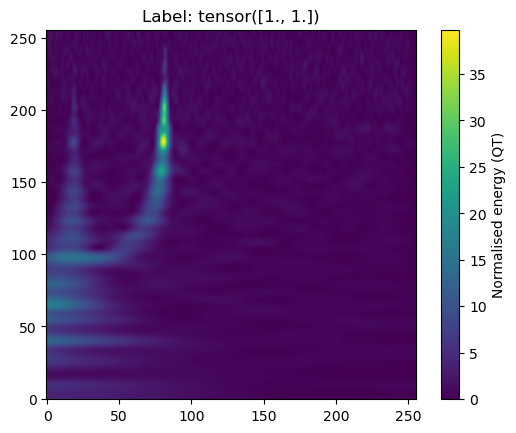

In [10]:
image, label = dataset[860]

plt.imshow(image[0], origin="lower")
plt.title(f"Label: {label}")
plt.colorbar(label='Normalised energy (QT)')
#plt.yscale("log")
plt.show()

## InceptionV3

In [ ]:
model = models.inception_v3(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)
model.aux_logits = False
model.AuxLogits = None
#for param in model.parameters():
#   param.requires_grad = False
#for param in model.fc.parameters():
#   param.requires_grad = True

In [ ]:
train_model(model, train_dataset, val_dataset, batch_size=32, learning_rate=0.001)

In [ ]:
small_train_dataset = torch.utils.data.Subset(train_dataset, range(10))
small_val_dataset = torch.utils.data.Subset(val_dataset, range(10))

train_model(model, small_train_dataset, small_val_dataset,
            batch_size=5, learning_rate=1e-3, num_epochs=200)

## Custom CNN from scratch

In [11]:
class CNN(nn.Module):
    def __init__(self, width=4, bn=True):
        
        super(CNN, self).__init__()
        self.width = width
        self.bn = bn
        # define all the conv layers
        self.conv1 = nn.Conv2d(in_channels=3,
                               out_channels=self.width,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(in_channels=self.width,
                               out_channels=self.width*2,
                               kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(in_channels=self.width*2,
                               out_channels=self.width*4,
                               kernel_size=3,
                               padding=1)
        self.conv4 = nn.Conv2d(in_channels=self.width*4,
                               out_channels=self.width*8,
                               kernel_size=3,
                               padding=1)
        # define all the BN layers
        if bn:
            self.bn1 = nn.BatchNorm2d(self.width)
            self.bn2 = nn.BatchNorm2d(self.width*2)
            self.bn3 = nn.BatchNorm2d(self.width*4)
            self.bn4 = nn.BatchNorm2d(self.width*8)
        # pooling layer has no parameter, so one such layer
        # can be shared across all conv layers
        self.pool = nn.MaxPool2d(2, 2)
        # FC layers
        self.fc1 = nn.Linear(self.width * 8 * 16 * 16, 100)
        self.fc2 = nn.Linear(100, 2)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        if self.bn:
            x = self.bn1(x)
        x = self.pool(torch.relu(self.conv2(x)))
        if self.bn:
            x = self.bn2(x)
        x = self.pool(torch.relu(self.conv3(x)))
        if self.bn:
            x = self.bn3(x)
        x = self.pool(torch.relu(self.conv4(x)))
        if self.bn:
            x = self.bn4(x)
        x = x.view(-1, self.width * 8 * 16 * 16)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [12]:
model = CNN(width=8, bn=True)
batch_size = 32
learning_rate = 0.001
num_epochs = 9
results = train_model(model, train_dataset, val_dataset,
                    batch_size=batch_size, learning_rate=learning_rate, 
                    num_epochs=num_epochs, plot_every=2, print_every=15)

Epoch 1/9, Iteration 15, Loss: 0.170,  Train Soft Acc: 0.751, Val Soft Acc: 0.717, Train Hard Acc: 0.510, Val Hard Acc: 0.439
Epoch 2/9, Iteration 30, Loss: 0.074,  Train Soft Acc: 0.797, Val Soft Acc: 0.755, Train Hard Acc: 0.596, Val Hard Acc: 0.526
Epoch 2/9, Iteration 45, Loss: 0.047,  Train Soft Acc: 0.772, Val Soft Acc: 0.731, Train Hard Acc: 0.563, Val Hard Acc: 0.498
Epoch 3/9, Iteration 60, Loss: 0.033,  Train Soft Acc: 0.785, Val Soft Acc: 0.749, Train Hard Acc: 0.575, Val Hard Acc: 0.506
Epoch 3/9, Iteration 75, Loss: 0.040,  Train Soft Acc: 0.813, Val Soft Acc: 0.767, Train Hard Acc: 0.631, Val Hard Acc: 0.538
Epoch 4/9, Iteration 90, Loss: 0.009,  Train Soft Acc: 0.835, Val Soft Acc: 0.781, Train Hard Acc: 0.679, Val Hard Acc: 0.585
Epoch 4/9, Iteration 105, Loss: 0.015,  Train Soft Acc: 0.788, Val Soft Acc: 0.737, Train Hard Acc: 0.589, Val Hard Acc: 0.518
Epoch 5/9, Iteration 120, Loss: 0.019,  Train Soft Acc: 0.900, Val Soft Acc: 0.854, Train Hard Acc: 0.803, Val Hard A

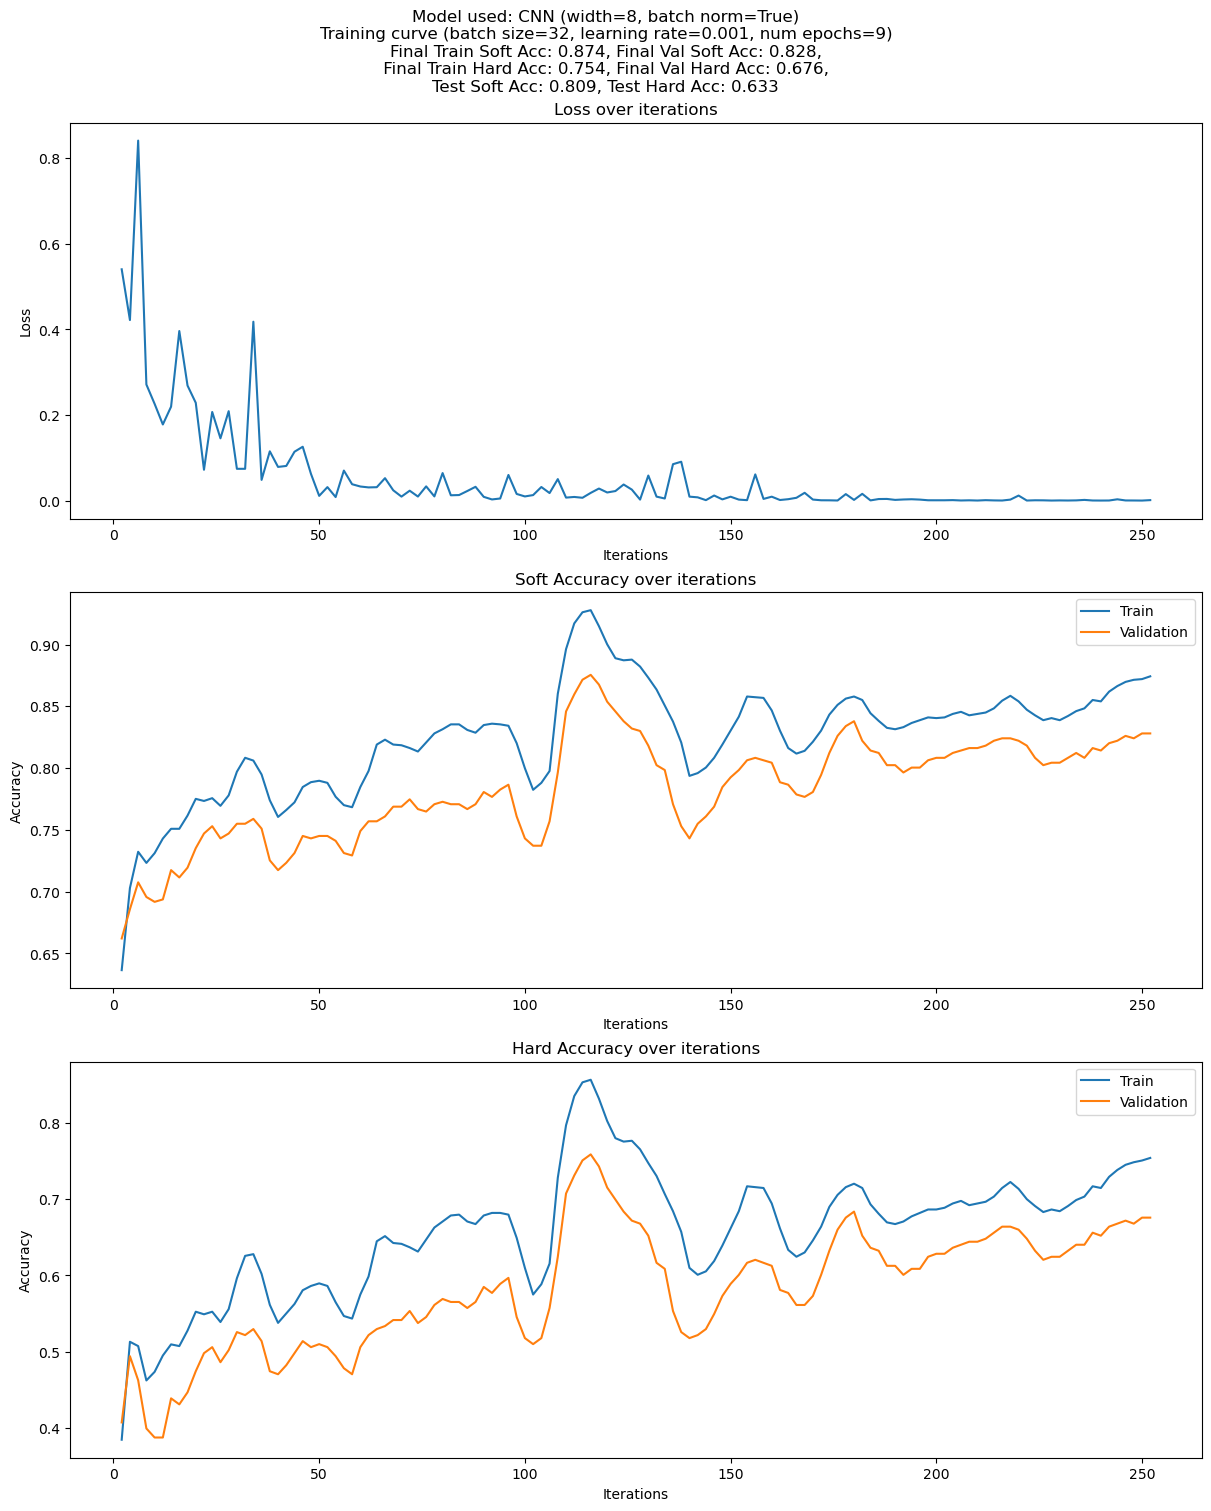

In [14]:
iters, train_loss, train_soft_acc, val_soft_acc, train_hard_acc, val_hard_acc = results
test_soft_acc = soft_accuracy(model, test_dataset)
test_hard_acc = hard_accuracy(model, test_dataset)

final_train_soft_acc = train_soft_acc[-1]
final_val_soft_acc = val_soft_acc[-1]
final_train_hard_acc = train_hard_acc[-1]
final_val_hard_acc = val_hard_acc[-1]

fig, axes = plt.subplots(3, 1, figsize=(12, 15), constrained_layout=True)
title = f"Model used: CNN (width={model.width}, batch norm={model.bn})\n" +\
f"Training curve (batch size={batch_size}, learning rate={learning_rate}, num epochs={num_epochs})\n" +\
f"Final Train Soft Acc: {final_train_soft_acc:.3f}, Final Val Soft Acc: {final_val_soft_acc:.3f},\n" +\
f" Final Train Hard Acc: {final_train_hard_acc:.3f}, Final Val Hard Acc: {final_val_hard_acc:.3f}, \n" +\
f"Test Soft Acc: {test_soft_acc:.3f}, Test Hard Acc: {test_hard_acc:.3f}"
fig.suptitle(title, fontsize=12)

axes[0].plot(iters[:len(train_loss)], train_loss)
axes[0].set_title("Loss over iterations")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss")

axes[1].plot(iters[:len(train_soft_acc)], train_soft_acc)
axes[1].plot(iters[:len(val_soft_acc)], val_soft_acc)
axes[1].set_title("Soft Accuracy over iterations")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Accuracy")
axes[1].legend(["Train", "Validation"])

axes[2].plot(iters[:len(train_hard_acc)], train_hard_acc)
axes[2].plot(iters[:len(val_hard_acc)], val_hard_acc)
axes[2].set_title("Hard Accuracy over iterations")
axes[2].set_xlabel("Iterations")
axes[2].set_ylabel("Accuracy")
axes[2].legend(["Train", "Validation"])

save_path = DIST/ 'training_curves'/ 'low_mass' /f"cnn_wid={model.width}_bn={model.bn}.png"
if not os.path.exists(save_path):
    plt.savefig(save_path)
    #pass
else:
    print(f"File already exists. Not saving the plot to avoid overwriting.")
plt.show()

In [160]:
(len(train_dataset)//batch_size + 1)*num_epochs

450

In [ ]:
weights_path = DIST / 'model_weights' / f"cnn_wid={model.width}_bn={model.bn}_v3.pth"
if not os.path.exists(weights_path):
    torch.save(model.state_dict(), weights_path)
else:
    print(f"File already exists. Not saving the model weights to avoid overwriting.")

In [166]:
total_iters = 250
n = total_iters / (len(train_dataset) // batch_size + 1)
n

8.333333333333334